# 06: Volt-VAr-induced curtailment: Methods A, B and C

Three methods that **bracket** the same quantity:

| | | |
|---|---|---|
| **A** | apparent-limit symptom scan | **upper bound**. Assumes every symptom interval was sun-limited |
| **B** | counterfactual attribution | **lower bound**. Counts only what clear-sky GHI confirms |
| **C** | derating-flag corroboration | not an estimate. Independent *label* to test A and B against |

A and B are reported as a **range** and are not reconciled. (note that averaging them wouldinvent a number neither method supports).

## sign caveat:
the reactive sign is not fully resolved

`exclude_polarity_suspect=True` (the default) drops the sites `se_adverse` flags as
`polarity_suspect` before scanning. That is a **cohort restriction**, not a correction —
it removes sites whose direction cannot be trusted rather than silently flipping them.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next((p for p in (_current, *_current.parents)
                  if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()), None)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_contract as contract, se_params
pd.set_option("display.max_columns", None); pd.set_option("display.width", 220)
con = se_store.connect()
config, params = se_params.CONFIG, se_params.PARAMS
from solar_edge.lib import se_curtailment as cu
from solar_edge.lib import se_plots as plots
from solar_edge.lib import se_adverse as adv

adverse = adv.classify_adverse_sites(con, config)
display(adverse.adverse_class.value_counts())
display(contract.manifest(config, params).query("section in ('detection','basis')"))

adverse_class
adverse_but_inactive    613
not_adverse             554
genuinely_adverse       314
polarity_suspect        109
Name: count, dtype: int64

,section,setting,value
27,basis,rating_basis,s_99
28,basis,empirical_limit_basis,s_99
29,basis,tolerance_basis,s_99
30,basis,tolerance_fraction,0.04
31,basis,voltage_aggregation,mean
32,basis,reactive_orientation,as_delivered
33,basis,site_nonconf_threshold,0.1
34,detection,voltage band,240 - 253 V
35,detection,peak hours (AEST),11:00 - 14:00
36,detection,require_apparent_limit_symptom,True


## Method A: apparent-limit symptom scan

An interval is flagged when the inverter is **absorbing** reactive power **and** sitting on its apparent-power circle:

```
Q_kvar < 0  AND  sqrt(P² + Q²) >= s_limit − tol × capacity
```

The proxy energy is the **headroom displacement**, `s_limit − sqrt(s_limit² − Q²)`: The kW of circle room that reactive absorption consumed.

**Two biases, both upward.** 

- It assumes the inverter would have used that headroom, which is only true when the sun was available. 
- And `s_limit` is `s_99`, an *observed* p99: a site that never approached its true inverter limit gets a low `s_limit`, so the test fires more readily. 

Method A here is an even looser upper bound givan it has no nameplate to anchor to.

In [2]:
method_a = cu.method_a_site_year(con, config, params, adverse=adverse, exclude_polarity_suspect=False)
display(cu.method_a_summary(method_a, config).T)

context = cu.eligible_context(con, config, params, adverse=adverse)
print(f"Eligible: {int(context.n_eligible_intervals.sum()):,} intervals "
      f"across {context.site_alias.nunique():,} sites")
print(f"Measured energy in those intervals: {context.measured_kWh.sum():,.0f} kWh")

,0,1
cohort,single-phase,three-phase
eligible_sites,1165,414
symptom_sites,208,410
eligible_intervals,11922806,4242805
absorbing_intervals,1502677,4173727
symptom_intervals,353466,605300
symptom_pct_of_eligible,2.9646,14.2665
headroom_displacement_kWh,4894.4,2483.2
symptom_with_derating_flag,278163,359401


Eligible: 15,554,919 intervals across 1,471 sites
Measured energy in those intervals: 5,494,423 kWh


##  Method B: counterfactual attribution

**Requires the GHI counterfactual.** The cell below raises a clear error if `se_uncurtailedpv` is absent rather than returning zeros.

Four evidence tiers, each strictly narrower than the last:

```
1  absorbing Q                                Q < 0
2  + apparent-limit symptom                   on the S-circle
3  + counterfactual above measured-Q headroom uncurtailed_P > pmax
4  + attributable displacement > 0            the reportable number
```

In [3]:
try:
    method_b = cu.method_b_site_year(con, config, params, adverse=adverse)
    display(cu.method_b_summary(method_b, config).T)
    display(cu.evidence_tiers(method_b))
except FileNotFoundError as exc:
    method_b = None
    print("Method B not runnable yet:\n"); print(exc)

,0,1
cohort,single-phase,three-phase
eligible_sites,1058,413
counterfactual_covered_sites,1058,413
eligible_intervals,11312789,4242130
counterfactual_covered_intervals,10650067,3991126
counterfactual_coverage_pct,94.14,94.08
tier1_absorbing,1444825,4173727
tier2_symptom,338769,605300
tier3_cf_above_headroom,144387,318744
tier4_attributed,88663,113600


,evidence_tier,n_intervals,n_sites,pct_of_tier1
0,Tier 1: absorbing Q,5618552,629,100.00
1,Tier 2: + apparent-limit symptom,944069,600,16.80
2,Tier 3: + counterfactual above measured-Q head...,463131,594,8.24
3,Tier 4: + attributable displacement,202263,483,3.60


## Fleet-level reporting

### Two denominators, three decimal places apart

`5.374 MWh` is the numerator throughout. What it is divided by changes the answer by
orders of magnitude, so a bare percentage means nothing without naming the denominator:

| Denominator | What it answers | Rough scale |
|---|---|---|
| **Eligible** potential generation — `sum(uncurtailed_P)` over covered 240–253 V peak intervals | *Of the generation that was at risk, how much was lost?* | ~5,600 MWh |
| **All** fleet generation — every interval, every site | *Of everything the fleet made, what did Volt-VAr cost?* | far larger |

The first is the exposure-conditional rate and is the fairer measure of how the mechanism
behaves when it acts. The second is the fleet-assurance number and is what a reader
assumes when handed an unqualified "% of generation".

**For the "all" denominator, prefer `measured_MWh`.** It is metered energy and needs no
model, so it cannot be wrong. `potential_MWh` coalesces to measured wherever no
counterfactual exists — and fleet-wide coverage is roughly 12%, versus ~94% inside the
eligible band, because the GHI model only fits where clear-sky training days exist. On the
uncovered majority the fallback is a *lower* bound on potential, so `potential_MWh` is
understated and any percentage using it is overstated. `pct_intervals_covered` is printed
so that bias is visible rather than assumed away.

In [4]:
cohort_sites = cu.cohort_site_count(con, config)
print(f"residential-scale cohort: {cohort_sites:,} sites")

# The SECOND denominator: all cohort generation, not just the screened 240-253 V band.
# This scans every interval in the store, so it is the slowest cell in the notebook.
fleet_generation = cu.fleet_potential_generation(con, config)
display(fleet_generation)

if method_b is not None:
    fleet_report = cu.fleet_curtailment_report(
        method_b, config, cohort_sites, fleet_generation)
    display(fleet_report)
else:
    fleet_report = None
    print("\nNeeds Method B -- build the D12 counterfactual first (notebook 04, section 5).")

residential-scale cohort: 1,580 sites


,n_sites,n_intervals,n_covered,pct_intervals_covered,measured_MWh,potential_MWh,covered_measured_MWh,covered_potential_MWh,counterfactual_available
0,1580,85290322,62807130,73.64,16900.9,18853.2,15803.7,17756.0,True


,statistic,value,note
0,cohort sites (outer denominator),1580,
1,sites with any eligible interval,1471,93.101% of cohort
2,sites showing the V-VAr symptom,600,37.975% of cohort | 40.789% of eligible
3,sites with effective energy loss,483,30.57% of cohort | 32.835% of eligible
4,"eligible timestamps (240-253 V, peak, clear-sky)",15554919,
5,counterfactual-covered timestamps,14641193,94.126% coverage
6,symptom timestamps,944069,6.069% of eligible
7,curtailed timestamps (attributed > 0),202263,1.3% of eligible
8,estimated V-VAr curtailment (kWh),5374.3,
9,estimated V-VAr curtailment (MWh),5.374,


In [24]:
(5.374/18853.2)*100

0.028504444868775587

### Concentration of the loss

The report's Figure 37: the share of total curtailment held by the top X% of *affected*
sites. Computed over sites with non-zero attributed energy, which is the denominator that
makes "the bottom half contribute 1%" a statement about affected sites rather than about
the whole fleet.

In [5]:
if method_b is not None:
    concentration = cu.curtailment_concentration(method_b, config)
    display(concentration)
    print(f"affected sites: {concentration.attrs['n_affected_sites']:,}   "
          f"total: {concentration.attrs['total_kWh']:,.1f} kWh")
else:
    concentration = None

,top_pct,n_sites,kWh,pct_of_total
0,1,5,562.6,10.5
1,5,24,1711.4,31.8
2,10,48,2664.8,49.6
3,20,97,3811.9,70.9
4,50,242,5170.5,96.2
5,bottom 50%,241,203.9,3.8


affected sites: 483   total: 5,374.3 kWh


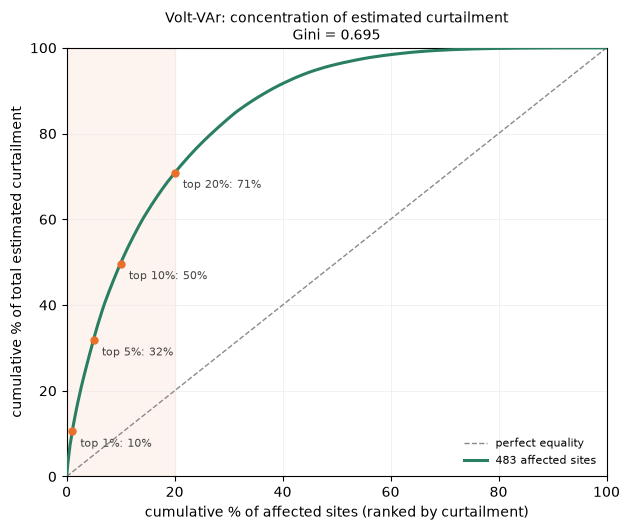

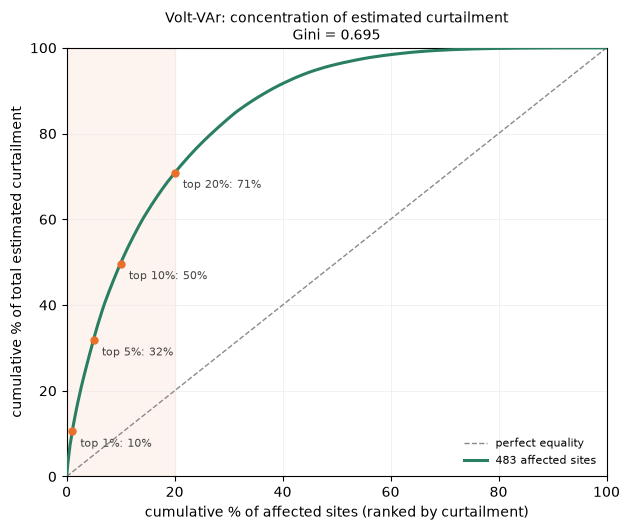

In [6]:
# Figure 37: the Lorenz curve behind the table above.
# Sites are ranked worst-first so the curve reads as "the top X% account for Y%".
# That is the reverse of a textbook Lorenz curve, so it bows ABOVE the diagonal.
if concentration is not None:
    display(plots.plot_curtailment_lorenz(
        concentration,
        "Volt-VAr: concentration of estimated curtailment",
        f"{concentration.attrs['n_affected_sites']:,} affected sites"))

### The paragraph

Generated from the frame, not transcribed. Every figure is substituted from `method_b`, so
the prose cannot drift from the analysis when the store is rebuilt — which is the failure
this is written to prevent.

Read it as a **lower bound**: Method B counts only the shortfall the clear-sky
counterfactual confirms. Method A is the upper bound, and the honest report gives the
range. The cell after prints both ends.

In [7]:
import textwrap

if method_b is not None:
    narrative = cu.fleet_curtailment_narrative(
        method_b, con, config, params, cohort_sites, concentration, fleet_generation)
    print(textwrap.fill(narrative, 96))
else:
    narrative = None

At fleet level, the same logic was applied across the residential-scale cohort defined above
(n=1,580), across 2025. Of these, 1,471 sites (93.1%) recorded at least one eligible interval,
and 600 sites (38.0% of the cohort; 40.8% of those eligible) showed the V-VAr curtailment
symptom, defined as reactive absorption during high-voltage, clear-sky solar periods while
operating near the apparent-power limit. The total estimated V-VAr-induced curtailment across
the analysed cohort was 5.374 MWh, equivalent to 0.096% of eligible modelled PV generation over
the screened intervals, or 1.300% of the eligible timestamps. Of the sites showing the symptom,
483 presented an effective loss of energy. Against all generation recorded by the cohort, rather
than only the screened intervals, the same loss is 0.0320%. The distribution of estimated
curtailment is highly concentrated among a small subset of sites: the top 1% account for 10%,
the top 5% account for 32%, the top 10% account for 50%, and the

In [8]:
# The A-B range, which the paragraph above deliberately does not collapse into one number.
if method_b is not None:
    a_kwh = method_a.headroom_displacement_kw_sum.sum() * config.interval_h
    b_kwh = method_b.attributed_kw_sum.sum() * config.interval_h
    print(f"Method A (upper bound, assumes every symptom interval was sun-limited): "
          f"{a_kwh / 1000:8.3f} MWh")
    print(f"Method B (lower bound, counterfactual-confirmed only):                  "
          f"{b_kwh / 1000:8.3f} MWh")
    print(f"ratio A/B: {a_kwh / b_kwh:.1f}x" if b_kwh else "")

Method A (upper bound, assumes every symptom interval was sun-limited):    7.378 MWh
Method B (lower bound, counterfactual-confirmed only):                     5.374 MWh
ratio A/B: 1.4x


In [9]:
if fleet_report is not None:
    fleet_report.to_csv(C.ARTEFACT_DIR / "fleet_curtailment_report.csv", index=False)
    concentration.to_csv(C.ARTEFACT_DIR / "curtailment_concentration.csv", index=False)
    (C.ARTEFACT_DIR / "fleet_curtailment_narrative.txt").write_text(narrative)
    print(f"-> {C.ARTEFACT_DIR / 'fleet_curtailment_report.csv'}")
    print(f"-> {C.ARTEFACT_DIR / 'curtailment_concentration.csv'}")
    print(f"-> {C.ARTEFACT_DIR / 'fleet_curtailment_narrative.txt'}")

-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\fleet_curtailment_report.csv
-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\curtailment_concentration.csv
-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\fleet_curtailment_narrative.txt


## Method C: derating-flag corroboration

SolarEdge reports `derating_active` per interval. 

This is **not a third estimate**, it is an independent label for the thing Method A is trying to infer.

**Read precision, not recall.** The raw flag is `1.0` or NULL, never `0.0`, so "not
derating" and "not reported" are indistinguishable. *Of the intervals the inverter says
it was derating, what fraction did Method A catch?* is sound. *Of the intervals Method A
missed, how many were really derating?* is unanswerable.

The flag is also not Volt-VAr specific — thermal limits, DC clipping and export control
all set it. Agreement corroborates "something limited output", not the mechanism.

In [10]:
confusion = cu.method_c_confusion(con, config, params, adverse=adverse)
display(confusion)
counts = confusion.attrs["counts"]
print(f"Method A symptom AND derating flag : {counts['tp']:,}")
print(f"Method A symptom, no flag          : {counts['fp']:,}")
print(f"Flag but no Method A symptom       : {counts['fn']:,}")
print(f"\nPrecision (interpretable)          : {confusion.attrs['precision']:.4f}")
print("Recall is NOT interpretable — see above.")

,method_a_symptom,derating_active,n_intervals,pct_of_eligible
0,True,True,626216,4.026
1,True,False,317853,2.043
2,False,True,3460823,22.249
3,False,False,11150027,71.682


Method A symptom AND derating flag : 626,216
Method A symptom, no flag          : 317,853
Flag but no Method A symptom       : 3,460,823

Precision (interpretable)          : 0.6633
Recall is NOT interpretable — see above.


### Is the flag tracking Volt-VAr or Volt-Watt?

The discriminator. If the derating rate only climbs above **253 V** it is tracking
Volt-Watt and says nothing about the 240–253 V band where Method A operates. A rise
*within* 240–253 V is what would make it corroborate a Volt-VAr claim.

In [11]:
by_v = cu.method_c_by_voltage(con, config)
display(by_v)

band = by_v[(by_v.v_bin >= 240) & (by_v.v_bin < 253)]
print(f"Derating rate at 240 V: {band.pct_derating.iloc[0]:.2f}%")
print(f"Derating rate at 252 V: {band.pct_derating.iloc[-1]:.2f}%")
print("A rise within this band supports a Volt-VAr reading; a flat line does not.")

,v_bin,n_intervals,n_derating,pct_derating,mean_P_kW,median_Q_kvar
0,235.0,1539649,69255,4.498,1.579,0.1308
1,236.0,2206238,106546,4.829,1.705,0.1285
2,237.0,3034274,158960,5.239,1.852,0.1258
3,238.0,3945880,225884,5.725,2.005,0.1240
4,239.0,4916144,319382,6.497,2.141,0.1239
5,240.0,5962500,440750,7.392,2.268,0.1248
6,241.0,6847161,579907,8.469,2.404,0.1262
7,242.0,7358534,720923,9.797,2.550,0.1286
8,243.0,7286345,828526,11.371,2.741,0.1325
9,244.0,6665134,881063,13.219,2.991,0.1365


Derating rate at 240 V: 7.39%
Derating rate at 252 V: 52.61%
A rise within this band supports a Volt-VAr reading; a flat line does not.


## Volt-Watt curtailment

For every interval with **V > 253 V** (Volt-Watt active), with
`ceiling = vw_max_p(V, s_99) + 4%`:

```
is_curtailed        =  uncurtailed_P > ceiling   AND   P_kW < ceiling

curtailed_kW        =  uncurtailed_P − P_kW          # total energy foregone
  mandated_kW       =  uncurtailed_P − ceiling       #   required by the standard
  over_reduction_kW =  ceiling − P_kW                #   shed beyond the requirement
```

`curtailed_kW = mandated_kW + over_reduction_kW` by construction.

The counterfactual is floored at measured P (`uncurtailed_P = greatest(prediction, P_kW)`),
so `curtailed_kW ≥ 0` always and the estimate can never claim a site produced less than
was observed.

### Lower bound due to GHI coverage

Intervals with no `uncurtailed_P` contribute **zero**, not "unknown". Every gap in the counterfactual pushes the total down.

In [12]:
try:
    vw_curt = cu.voltwatt_curtailment_site_year(con, config, params)
    vw_curt_summary = cu.voltwatt_curtailment_summary(vw_curt, config)
    display(vw_curt_summary.T)
    cu.voltwatt_curtailment_note(vw_curt_summary)

    vw_curt.to_csv(C.ARTEFACT_DIR / "voltwatt_curtailment_by_site.csv", index=False)
    print(f"\nPer-site -> {C.ARTEFACT_DIR / 'voltwatt_curtailment_by_site.csv'}")
except FileNotFoundError as exc:
    vw_curt = None
    print("Volt-Watt curtailment not runnable yet:\n"); print(exc)

,0,1
cohort,single-phase,three-phase
n_sites,503,70
sites_with_curtailment,324,20
exposed_intervals,631154,4285
counterfactual_covered,604606,3866
pct_exposed_covered,95.79,90.22
response_opportunity_intervals,198382,200
curtailed_intervals,78908,159
curtailed_kWh,6185.25,31.91
mandated_kWh,3134.81,12.45


Volt-Watt curtailment
  6,217.2 kWh not generated while Volt-Watt was active
    3,147.3 kWh (50.6%) required by the standard
    3,069.9 kWh (49.4%) shed BEYOND the requirement

  Coverage: 608,472 of 635,439 exposed intervals (95.8%) have a counterfactual.
  Uncovered intervals contribute ZERO, so this is a LOWER bound and it
  scales with coverage. Quote the two together or not at all.

Per-site -> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\voltwatt_curtailment_by_site.csv


#### Which sites, and how much

`response_opportunity_count` is the honest denominator for "did this site curtail":
intervals where the counterfactual says power was available above the ceiling. A site with
zero response opportunities was never asked, and its zero curtailment says nothing.

In [13]:
if vw_curt is not None and len(vw_curt):
    top = vw_curt[vw_curt.curtailed_count > 0].copy()
    top["curtailed_kWh"] = (top.curtailed_kw_sum * C.INTERVAL_H).round(2)
    top["over_reduction_kWh"] = (top.over_reduction_kw_sum * C.INTERVAL_H).round(2)
    top["pct_opportunities_curtailed"] = (
        100 * top.curtailed_count / top.response_opportunity_count.replace(0, pd.NA)
    ).round(1)
    display(top.nlargest(15, "curtailed_kWh")[
        ["site_alias", "state", "rating_kva", "exposed_count",
         "counterfactual_covered_count", "response_opportunity_count",
         "curtailed_count", "pct_opportunities_curtailed",
         "curtailed_kWh", "over_reduction_kWh"]])

    print(f"\n{len(top):,} of {len(vw_curt):,} exposed sites show any Volt-Watt "
          f"curtailment.")
    print(f"{int((vw_curt.response_opportunity_count == 0).sum()):,} sites had NO "
          f"response opportunity at all — their zero is uninformative.")

,site_alias,state,rating_kva,exposed_count,counterfactual_covered_count,response_opportunity_count,curtailed_count,pct_opportunities_curtailed,curtailed_kWh,over_reduction_kWh
441,AUS351,Queensland,4.995370,18422,17860,6515,6181,94.9,444.18,111.96
223,AUS1391,Queensland,4.950669,8071,7398,3520,1689,48.0,299.24,196.82
330,AUS066,Queensland,7.668667,14895,14380,6550,3477,53.1,256.00,41.01
394,AUS1508,South Australia,5.678932,9367,9009,3000,2394,79.8,164.66,65.87
540,AUS1352,South Australia,7.364619,9994,9591,3328,1532,46.0,141.70,63.37
30,AUS156,South Australia,9.961250,3529,3385,919,900,97.9,140.18,73.39
555,AUS945,New South Wales,4.940558,3744,3590,1625,1476,90.8,131.78,52.86
350,AUS887,Queensland,5.116117,9419,9047,2157,2077,96.3,122.43,52.37
140,AUS805,New South Wales,5.000861,2570,2444,1312,1286,98.0,121.67,62.76
75,AUS034,New South Wales,9.685818,4691,4493,1004,890,88.6,117.09,57.83



344 of 573 exposed sites show any Volt-Watt curtailment.
197 sites had NO response opportunity at all — their zero is uninformative.


#### Fleet-level reporting — Volt-Watt

The same reporting frame as the Volt-VAr section, with three deliberate differences in
what the rows mean:

- **"exposed", not "eligible".** Volt-VAr is assessed over 240–253 V, Volt-Watt only above
  253 V. The two populations are disjoint by construction, so the totals are additive
  rather than overlapping — that separation is what makes either attributable.
- **No symptom tier.** Volt-Watt needs no proxy. The standard states the ceiling, so
  "the sun could have delivered more than the ceiling allowed" is directly checkable.
  `response_opportunity` replaces the symptom count.
- **The total splits.** `mandated` is the designed cost of the standard; `over_reduction`
  is what inverters shed beyond what was asked. Only the second is a compliance finding —
  reporting the sum alone conflates a working standard with a badly tuned inverter.

In [14]:
if vw_curt is not None and len(vw_curt):
    vw_fleet_report = cu.voltwatt_fleet_report(vw_curt, config, cohort_sites)
    display(vw_fleet_report)
else:
    vw_fleet_report = None

,statistic,value,note
0,cohort sites (outer denominator),1580,
1,sites exposed to Volt-Watt (V > 253 V),573,36.266% of cohort
2,sites with a response opportunity,376,23.797% of cohort | 65.62% of exposed
3,sites with effective energy loss,344,21.772% of cohort | 60.035% of exposed
4,exposed timestamps (V > 253 V),635439,
5,counterfactual-covered timestamps,608472,95.756% coverage
6,response-opportunity timestamps,198582,31.251% of exposed
7,curtailed timestamps,79067,12.443% of exposed
8,estimated Volt-Watt curtailment (kWh),6217.2,
9,estimated Volt-Watt curtailment (MWh),6.217,


In [25]:
(6.217/18853.2)*100

0.03297583434111981

,top_pct,n_sites,kWh,pct_of_total
0,1,3,999.4,16.1
1,5,17,2665.0,42.9
2,10,34,3869.8,62.2
3,20,69,5154.7,82.9
4,50,172,6095.3,98.0
5,bottom 50%,172,121.9,2.0


affected sites: 344   total: 6,217.2 kWh


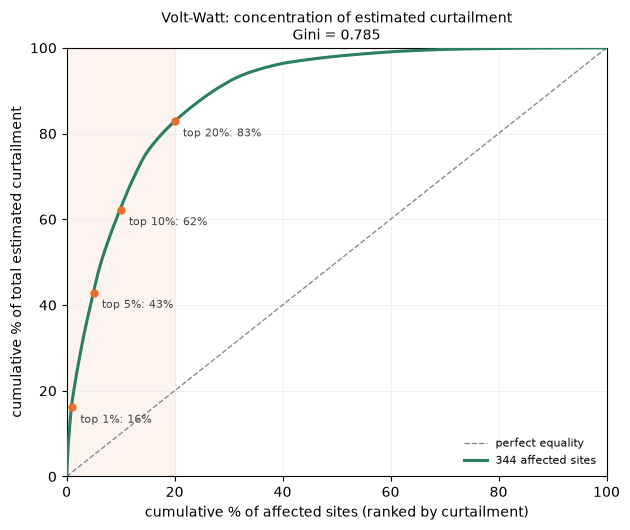

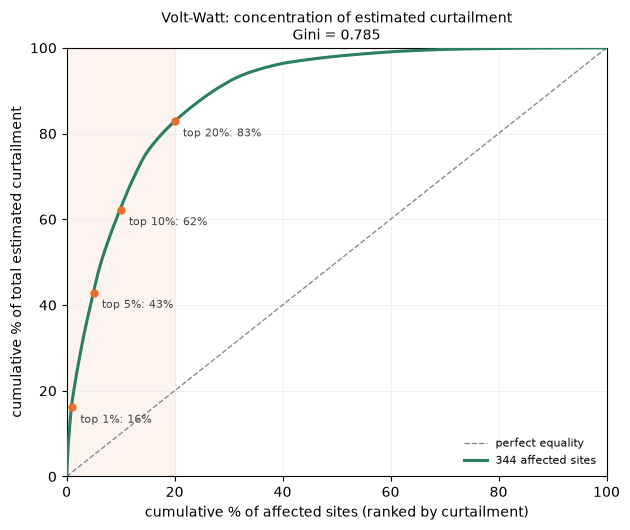

In [15]:
if vw_curt is not None and len(vw_curt):
    vw_concentration = cu.curtailment_concentration(vw_curt, config, mode="voltwatt")
    display(vw_concentration)
    print(f"affected sites: {vw_concentration.attrs['n_affected_sites']:,}   "
          f"total: {vw_concentration.attrs['total_kWh']:,.1f} kWh")
    display(plots.plot_curtailment_lorenz(
        vw_concentration,
        "Volt-Watt: concentration of estimated curtailment",
        f"{vw_concentration.attrs['n_affected_sites']:,} affected sites"))
else:
    vw_concentration = None

In [16]:
if vw_fleet_report is not None:
    vw_narrative = cu.voltwatt_curtailment_narrative(
        vw_curt, con, config, cohort_sites, vw_concentration)
    print(textwrap.fill(vw_narrative, 96))

    vw_fleet_report.to_csv(C.ARTEFACT_DIR / "voltwatt_fleet_report.csv", index=False)
    vw_concentration.to_csv(
        C.ARTEFACT_DIR / "voltwatt_curtailment_concentration.csv", index=False)
    (C.ARTEFACT_DIR / "voltwatt_curtailment_narrative.txt").write_text(vw_narrative)
    print(f"\n-> {C.ARTEFACT_DIR / 'voltwatt_fleet_report.csv'}")
    print(f"-> {C.ARTEFACT_DIR / 'voltwatt_curtailment_narrative.txt'}")
else:
    vw_narrative = None

The same counterfactual was applied to Volt-Watt across the residential-scale cohort (n=1,580).
Of these, 573 sites (36.3%) were exposed to Volt-Watt at least once, defined as an average site
voltage above 253 V, and 344 sites (21.8% of the cohort; 60.0% of those exposed) showed an
effective loss of energy. The total estimated Volt-Watt curtailment was 6.217 MWh, equivalent to
2.321% of modelled PV generation over the exposed intervals, or 12.443% of the exposed
timestamps. Of that total, 50.6% (3.147 MWh) was mandated by the standard's power ceiling and
49.4% (3.070 MWh) was reduction beyond that requirement. Only the second component represents
inverter behaviour that the standard did not ask for. The loss is similarly concentrated: the
top 1% account for 16%, the top 5% account for 43%, the top 10% account for 62%, and the top 20%
account for 83% of the total. Unlike the Volt-VAr figures, this population is disjoint by
construction: Volt-VAr is assessed over 240-253 V and Volt-Watt 

#### Volt-VAr vs Volt-Watt curtailment

Two different mechanisms competing for the same headroom. Volt-VAr curtailment is a side
effect of reactive absorption; Volt-Watt curtailment is the standard doing exactly what it
says. Comparing the energies says which one actually costs generation on this fleet —
subject, as always, to Method B's coverage and this calculation's coverage being
different numbers.

In [17]:
if vw_curt is not None and method_b is not None:
    vv_kwh = float(method_b.attributed_kw_sum.sum()) * C.INTERVAL_H
    vw_kwh = float(vw_curt.curtailed_kw_sum.sum()) * C.INTERVAL_H
    display(pd.DataFrame([
        {"mechanism": "Volt-VAr (Method B, counterfactual)",
         "kWh": round(vv_kwh, 2),
         "coverage_note": "attributed only where uncurtailed_P exists"},
        {"mechanism": "Volt-Watt (ceiling vs counterfactual)",
         "kWh": round(vw_kwh, 2),
         "coverage_note": f"{vw_curt_summary.counterfactual_covered.sum():,.0f} of "
                          f"{vw_curt_summary.exposed_intervals.sum():,.0f} exposed "
                          f"intervals covered"},
    ]))
    print("Both are LOWER bounds and their coverage differs — do not read the ratio")
    print("as a physical result until counterfactual coverage is comparable.")
else:
    print("Needs both method_b and vw_curt.")

,mechanism,kWh,coverage_note
0,"Volt-VAr (Method B, counterfactual)",5374.35,attributed only where uncurtailed_P exists
1,Volt-Watt (ceiling vs counterfactual),6217.16,"608,472 of 635,439 exposed intervals covered"


Both are LOWER bounds and their coverage differs — do not read the ratio
as a physical result until counterfactual coverage is comparable.


## A vs B vs C

The range, stated as a range.

In [18]:
display(cu.method_comparison(method_a, method_b, confusion, config))

method_a.to_csv(C.ARTEFACT_DIR / "method_a_by_site.csv", index=False)
print(f"-> {C.ARTEFACT_DIR / 'method_a_by_site.csv'}")

,method,bound,sites_flagged,intervals_flagged,energy_kWh,note
0,A -- apparent-limit symptom scan,upper,618.0,958766,7377.6,assumes every symptom interval was sun-limited
1,B -- counterfactual attribution,lower,483.0,202263,5374.3,counterfactual-confirmed only; contaminated tr...
2,C -- derating-flag corroboration,"label, not an estimate",NaN,4087039,NaN,precision of Method A against the flag: 0.663


-> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\method_a_by_site.csv


## What this establishes

- **Method A** gives an upper-bound curtailment estimate, with both of its upward biases
  stated (sun-limited assumption, and `s_99` as an observed limit).
- **Method C** gives a precision figure for Method A against SolarEdge's own derating
  flag — a validation no Solar Analytics dataset could support.
- **Method B** is coded and will run the moment D12 lands.

Sensitivity for all of this is in `07_sensitivity.ipynb`.